### 1. Train FHMM Step by Step

In [1]:
import os

# --- Kaggle perf: gioi han so luong BLAS/OpenMP cho moi process ---
# Phai dat TRUOC khi numpy/pandas duoc import lan dau, de cac worker
# do joblib (Parallel) sinh ra sau nay khong bi "oversubscribe" CPU
# (nhieu process x nhieu thread BLAS cung tranh nhau vai core cua Kaggle).
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

import pandas as pd
import numpy as np

# Kaggle-friendly path setup
if os.path.exists('/kaggle/input'):
    data_dir = '/kaggle/input/nilm-refit-house2-processed'  # Update dataset name if different
    work_dir = '/kaggle/working'  # /kaggle/input chi DOC -> moi file ghi ra phai de o day
else:
    data_dir = '../../data/processed_data'  # Local fallback
    work_dir = data_dir

os.makedirs(work_dir, exist_ok=True)
print(f"data_dir (read):  {data_dir}")
print(f"work_dir (write): {work_dir}")


data_dir (read):  /kaggle/input/nilm-refit-house2-processed
work_dir (write): /kaggle/working


### Luu y toc do khi chay tren Kaggle

- **Tat GPU Accelerator** (Settings -> Accelerator -> None). `hmmlearn` (GaussianHMM) chi chay tren CPU, khong ho tro GPU/TPU -- bat GPU khong giup gi ma con khien Kaggle **cap it CPU hon** (2 core thay vi 4) va ton quota GPU hang tuan.
- Notebook da dung `joblib.Parallel` de train nhieu HMM song song tren cac core CPU ma Kaggle cap (xem cell train FHMM va cell grid search).
- Da gioi han so luong BLAS/OpenMP threads = 1 cho moi process con de tranh tranh chap CPU khi chay song song (xem cell ngay tren).


### 2. Import Libraries

In [2]:
import sys
import os
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

### 3. Set Project Path

### 4. Load Data


In [3]:
csv_path = '/kaggle/input/datasets/meowll/nilm-data/House2_full.csv'
print(f'Loading data from: {csv_path}')
df = pd.read_csv(csv_path)
print(f'Number of rows: {len(df):,}')
print(f'Number of columns: {len(df.columns)}')
print(f'Column names: {df.columns.tolist()}')


Loading data from: /kaggle/input/datasets/meowll/nilm-data/House2_full.csv
Number of rows: 5,733,526
Number of columns: 12
Column names: ['Time', 'Unix', 'Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']


### 6. Process Time Column

In [4]:
df['Time'] = pd.to_datetime(df['Time'])

print(f"Time data type: {df['Time'].dtype}") 
print(f"Start time: {df['Time'].min()}")
print(f"End time: {df['Time'].max()}")
print(f"Time interval: {df['Time'].max() - df['Time'].min()}")

time_diff = df['Time'].diff().dropna()
print(f"Mean distance between samples: {time_diff.mean()}")
print(f"Most common distance: {time_diff.mode()[0]}")

Time data type: datetime64[ns]
Start time: 2013-09-17 22:08:11
End time: 2015-05-28 08:05:43
Time interval: 617 days 09:57:32
Mean distance between samples: 0 days 00:00:09.303988732
Most common distance: 0 days 00:00:07


### 7. Calculate Appliance_Others

In [5]:
appliance_cols = ['Appliance1', 'Appliance2', 'Appliance3', 
                  'Appliance4', 'Appliance5', 'Appliance6',
                  'Appliance7', 'Appliance8', 'Appliance9']

df['sum_9_appliances'] = df[appliance_cols].sum(axis=1)

df['Appliance_Others'] = df['Aggregate'] - df['sum_9_appliances']

negative_count = (df['Appliance_Others'] < 0).sum()
print(f"Number of rows with Appliance_Others < 0 (to be deleted): {negative_count:,}")

df = df[df['Appliance_Others'] >= 0].copy()
print(f"The {negative_count:,} line has been removed. The current minimum value is: {df['Appliance_Others'].min()}")

df.drop(columns=['sum_9_appliances'], inplace=True)

print("Appliance_Others Distribution BEFORE Filtering")
print(df['Appliance_Others'].describe(percentiles=[.01, .25, .5, .75, .99, .999]))
print(f"\nNumber of negative rows : {(df['Appliance_Others'] < 0).sum():,}")
print(f"Absolute Max: {df['Appliance_Others'].max():.1f} W")

upper_bound = df['Aggregate'].quantile(0.999)
print(f"99.9th percentile of Aggregate = {upper_bound:.1f} W")
print(f"Max Aggregate in dataset= {df['Aggregate'].max():.1f} W\n")

df['Appliance_Others'] = df['Appliance_Others'].clip(lower=0, upper=upper_bound)

print(f"Summary of Appliance_Others AFTER edge lamination")
print(df['Appliance_Others'].describe())

Number of rows with Appliance_Others < 0 (to be deleted): 28,444
The 28,444 line has been removed. The current minimum value is: 0
Appliance_Others Distribution BEFORE Filtering
count    5.705082e+06
mean     3.214029e+02
std      9.227989e+02
min      0.000000e+00
1%       5.200000e+01
25%      8.300000e+01
50%      1.120000e+02
75%      2.300000e+02
99%      3.456000e+03
99.9%    1.034700e+04
max      2.438700e+04
Name: Appliance_Others, dtype: float64

Number of negative rows : 0
Absolute Max: 24387.0 W
99.9th percentile of Aggregate = 10503.8 W
Max Aggregate in dataset= 24595.0 W

Summary of Appliance_Others AFTER edge lamination
count    5.705082e+06
mean     3.209236e+02
std      9.169878e+02
min      0.000000e+00
25%      8.300000e+01
50%      1.120000e+02
75%      2.300000e+02
max      1.050376e+04
Name: Appliance_Others, dtype: float64


### 8. Add Time Features

Why are time features needed?

- Washing machines often run between 8-10 AM or 7-9 PM.

- Microwaves are often used during mealtimes (12 PM, 6 PM).

- When the model knows "it's 3 AM," it will predict fewer appliances will be turned on.

In [6]:
df['hour'] = df['Time'].dt.hour
df['minute'] = df['Time'].dt.minute
df['dayofweek'] = df['Time'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

print("Time features added")
print(df[['Time', 'hour', 'minute', 'dayofweek', 'is_weekend']].head(3))

Time features added
                 Time  hour  minute  dayofweek  is_weekend
0 2013-09-17 22:08:11    22       8          1           0
1 2013-09-17 22:08:18    22       8          1           0
2 2013-09-17 22:08:26    22       8          1           0


### 9. Chronological Split (70/10/20)

In [7]:
df = df.sort_values('Time').reset_index(drop=True)

total_rows = len(df)
train_end  = int(total_rows * 0.70)
val_end    = int(total_rows * 0.80)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()  

print(f"Total rows: {total_rows:,}")
print(f"Train: {len(df_train):,} rows ({len(df_train)/total_rows*100:.1f}%)")
print(f"Val: {len(df_val):,} rows ({len(df_val)/total_rows*100:.1f}%)")
print(f"Test: {len(df_test):,} rows ({len(df_test)/total_rows*100:.1f}%)")
print(f"\nTrain: {df_train['Time'].min()} → {df_train['Time'].max()}")
print(f"Val: {df_val['Time'].min()} → {df_val['Time'].max()}")
print(f"Test: {df_test['Time'].min()} → {df_test['Time'].max()}")

assert df_train['Time'].max() < df_val['Time'].min()
assert df_val['Time'].max()   < df_test['Time'].min()
print("\nNo overlap between sets")

Total rows: 5,705,082
Train: 3,993,557 rows (70.0%)
Val: 570,508 rows (10.0%)
Test: 1,141,017 rows (20.0%)

Train: 2013-09-17 22:08:11 → 2014-12-27 07:02:28
Val: 2014-12-27 07:02:35 → 2015-02-10 05:23:26
Test: 2015-02-10 05:23:33 → 2015-05-28 08:05:43

No overlap between sets


### 11. Separate Features and Targets

After this data splitting step:

|Variable|Function|
|-|-|
|`y_train`|`fit()` - train model|
|`agg_val`, `y_val`|grid search — select `n_states`/`n_iter`|
|`agg_test`, `y_test`|Final evaluation — OPENED ONLY ONCE|

In [8]:
target_cols = ['Appliance1', 'Appliance2', 'Appliance3',
               'Appliance4', 'Appliance5', 'Appliance6',
               'Appliance7', 'Appliance8', 'Appliance9',
               'Appliance_Others']

y_train = df_train[target_cols]

agg_val = df_val['Aggregate'].values
y_val   = df_val[target_cols]

agg_test = df_test['Aggregate'].values
y_test  = df_test[target_cols]

print("Sizes of the sets: ")
print(f"  y_train:  {y_train.shape}")
print(f"  agg_val:  {agg_val.shape}     y_val:   {y_val.shape}")
print(f"  agg_test: {agg_test.shape}   y_test:  {y_test.shape}")


Sizes of the sets: 
  y_train:  (3993557, 10)
  agg_val:  (570508,)     y_val:   (570508, 10)
  agg_test: (1141017,)   y_test:  (1141017, 10)


### 12. Define the FHMM Class

Factorial HMM uses mean-field approximation.

Train K independent HMMs (K = number of devices).

Idea:

- Each device = 1 separate HMM

- Train each HMM at its own power level

- When predicting: use Aggregate to find the best hidden state

Mean-Field Residual Inference (Coordinate Descent) - Predict the power output of each appliance from Aggregate

- Loop 1, appliance_A (refrigerator):

    - other = appliance_B_est + appliance_C_est + ... = 2300W

    - resid  = agg - other = 2500 - 2300 = 200W

    - states = HMM_refrigerator.predict([200W])

    - refrigerator_est = 150W  (state ON)

- Repeat this process for each appliance, then repeat it twice to complete the cycle.

In [9]:
import importlib.util
if importlib.util.find_spec('hmmlearn') is None:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'hmmlearn'])

from hmmlearn import hmm
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

OTHERS_COL = 'Appliance_Others'

class SimpleFHMM:
    def __init__(self, n_states_per_appliance: dict = None, n_states: int = 2, n_iter: int = 100):
        self.n_states_per_appliance = n_states_per_appliance or {}
        self.n_states = n_states
        self.n_iter = n_iter
        self.models = {}
        self.is_fitted = False
    
    def _get_n_states(self, col_name):
        return self.n_states_per_appliance.get(col_name, self.n_states)
    
    def fit(self, y_train: pd.DataFrame):
        # Chỉ train HMM cho các thiết bị THỰC (bỏ qua Appliance_Others)
        train_cols = [c for c in y_train.columns if c != OTHERS_COL]
        print(f"Training {len(train_cols)} HMM models (excluding {OTHERS_COL})...")
        
        def train_single_hmm(col_name, obs_data, n_states, n_iter):
            model = hmm.GaussianHMM(
                n_components=n_states,
                covariance_type="diag",
                n_iter=n_iter,
                random_state=42
            )
            model.fit(obs_data)
            return col_name, model

        results = Parallel(n_jobs=-1, verbose=5)(  # -1 = dung TOAN BO core CPU Kaggle cap (batch job, khong can de chua 1 core)
            delayed(train_single_hmm)(
                col, y_train[col].values.reshape(-1, 1),
                self._get_n_states(col), self.n_iter
            )
            for col in train_cols
        )

        for col, trained_model in results:
            self.models[col] = trained_model
            means = sorted(trained_model.means_.flatten().round(1))
            print(f"Done [{col}] (n_states={trained_model.n_components}): {means}")
        
        self.is_fitted = True
        print("\nTraining complete!")
        return self
  
    def predict(self, agg_power: np.ndarray, n_coord_iter: int = 5) -> pd.DataFrame:
        if not self.is_fitted:
            raise RuntimeError("Not yet trained! Call fit() first.")

        cols = list(self.models.keys())  # Chỉ có 9 thiết bị thực
        N = len(agg_power)

        pred_power = {
            col: np.full(N, max(self.models[col].means_.min(), 0.0))
            for col in cols
        }

        for _iter in range(n_coord_iter):
            for col in cols:
                model = self.models[col]
                other_power = sum(pred_power[c] for c in cols if c != col)
                residual = (agg_power - other_power).clip(min=0)
                states = model.predict(residual.reshape(-1, 1))
                pred_power[col] = np.array(
                    [model.means_[s, 0] for s in states]
                ).clip(min=0)

        # Appliance_Others = Aggregate - tổng 9 thiết bị (luôn >= 0)
        sum_9 = sum(pred_power[c] for c in cols)
        pred_power[OTHERS_COL] = (agg_power - sum_9).clip(min=0)

        return pd.DataFrame(pred_power)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.8 MB/s eta 0:00:00


### 13. Train Model

The dataset is very large, so training will take a long time. For quick testing, use the first 200,000 points.

Once the model is stable, retrain it with the full dataset.

In [10]:
QUICK_TRAIN = True

if QUICK_TRAIN:
    y_train_subset = y_train.iloc[:200_000]
    print(f"Use {len(y_train_subset):,} instances for training (quick mode)")
else:
    y_train_subset = y_train
    print(f"Use full {len(y_train_subset):,} instances for training")

fhmm = SimpleFHMM(n_states=2, n_iter=100)
fhmm.fit(y_train_subset)

Use 200,000 instances for training (quick mode)
Training 9 HMM models (excluding Appliance_Others)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
Model is not converging.  Current: -908431.5292608687 is not greater than -908431.5292570499. Delta is -3.818771801888943e-06
[Parallel(n_jobs=-1)]: Done   4 out of   9 | elapsed:    5.8s remaining:    7.3s
Model is not converging.  Current: 1361676.7657418374 is not greater than 1361676.7657419336. Delta is -9.615905582904816e-08
[Parallel(n_jobs=-1)]: Done   6 out of   9 | elapsed:    6.7s remaining:    3.3s


Done [Appliance1] (n_states=2): [np.float64(4.8), np.float64(85.5)]
Done [Appliance2] (n_states=2): [np.float64(3.3), np.float64(2056.1)]
Done [Appliance3] (n_states=2): [np.float64(3.5), np.float64(2203.6)]
Done [Appliance4] (n_states=2): [np.float64(0.4), np.float64(46.9)]
Done [Appliance5] (n_states=2): [np.float64(0.0), np.float64(441.5)]
Done [Appliance6] (n_states=2): [np.float64(0.0), np.float64(672.0)]
Done [Appliance7] (n_states=2): [np.float64(0.0), np.float64(17.9)]
Done [Appliance8] (n_states=2): [np.float64(0.0), np.float64(2336.5)]
Done [Appliance9] (n_states=2): [np.float64(0.0), np.float64(49.9)]

Training complete!


[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    7.6s finished


### 14. Inspect HMM Models

In [11]:
print("Information about the trained models.")

for col, model in fhmm.models.items():
    means = sorted(model.means_.flatten()) 
    print(f"\n{col}:")
    print(f"  State means (W): {[f'{m:.1f}' for m in means]}")
    print(f"  Transition matrix:")
    for row in model.transmat_:
        print(f"    {[f'{p:.3f}' for p in row]}")

Information about the trained models.

Appliance1:
  State means (W): ['4.8', '85.5']
  Transition matrix:
    ['0.998', '0.002']
    ['0.003', '0.997']

Appliance2:
  State means (W): ['3.3', '2056.1']
  Transition matrix:
    ['1.000', '0.000']
    ['0.005', '0.995']

Appliance3:
  State means (W): ['3.5', '2203.6']
  Transition matrix:
    ['1.000', '0.000']
    ['0.010', '0.990']

Appliance4:
  State means (W): ['0.4', '46.9']
  Transition matrix:
    ['1.000', '0.000']
    ['0.002', '0.998']

Appliance5:
  State means (W): ['0.0', '441.5']
  Transition matrix:
    ['1.000', '0.000']
    ['0.063', '0.937']

Appliance6:
  State means (W): ['0.0', '672.0']
  Transition matrix:
    ['1.000', '0.000']
    ['0.046', '0.954']

Appliance7:
  State means (W): ['0.0', '17.9']
  Transition matrix:
    ['1.000', '0.000']
    ['0.001', '0.999']

Appliance8:
  State means (W): ['0.0', '2336.5']
  Transition matrix:
    ['0.939', '0.061']
    ['0.001', '0.999']

Appliance9:
  State means (W): ['

### 15. Grid Search for Hyperparameters

In [12]:
from sklearn.metrics import mean_absolute_error
from joblib import Parallel, delayed
from itertools import product
from collections import defaultdict

CANDIDATE_STATES = [2, 3, 4, 5, 6]
N_ITER_FIXED = 100
TRAIN_SUBSET = 200_000
y_train_sub = y_train.iloc[:TRAIN_SUBSET]

tunable_cols = [c for c in target_cols if c != OTHERS_COL]

print("=" * 70)
print("GRID SEARCH - TIM n_states TOI UU CHO TUNG THIET BI (song song)")
print("=" * 70)

def _fit_and_score(col, ns):
    model = hmm.GaussianHMM(
        n_components=ns, covariance_type="diag",
        n_iter=N_ITER_FIXED, random_state=42
    )
    # Train tren du lieu CUA CHINH thiet bi do
    model.fit(y_train_sub[col].values.reshape(-1, 1))

    # Danh gia tren du lieu CUA CHINH thiet bi do (tap Val)
    # -> Do luong kha nang mo hinh hoa hanh vi thiet bi
    states = model.predict(y_val[col].values.reshape(-1, 1))
    pred = np.array([model.means_[s, 0] for s in states]).clip(min=0)

    mae = mean_absolute_error(y_val[col].values, pred)
    means = sorted(model.means_.flatten().round(1))
    return col, ns, mae, means

# 9 thiet bi x 5 candidate states = 45 to hop doc lap -> chay het
# tren joblib.Parallel mot lan thay vi vong lap tuan tu nhu truoc,
# tan dung toan bo so core CPU ma Kaggle cap.
combos = list(product(tunable_cols, CANDIDATE_STATES))
results = Parallel(n_jobs=-1, verbose=5)(
    delayed(_fit_and_score)(col, ns) for col, ns in combos
)

by_col = defaultdict(list)
for col, ns, mae, means in results:
    by_col[col].append((ns, mae, means))

best_n_states_per_appliance = {}

for col in tunable_cols:
    print(f"\n--- {col} ---")
    for ns, mae, means in sorted(by_col[col], key=lambda x: x[0]):
        print(f"  n_states={ns}  MAE={mae:.2f}W  means={means}")

    best_ns, best_mae, _ = min(by_col[col], key=lambda x: x[1])
    best_n_states_per_appliance[col] = best_ns
    print(f"  >>> BEST: n_states={best_ns}, MAE={best_mae:.2f}W")

print("\n" + "=" * 70)
print("KET QUA TONG HOP:")
for col, ns in best_n_states_per_appliance.items():
    print(f"  {col}: n_states = {ns}")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


GRID SEARCH - TIM n_states TOI UU CHO TUNG THIET BI (song song)


Model is not converging.  Current: -908431.5292608687 is not greater than -908431.5292570499. Delta is -3.818771801888943e-06
Model is not converging.  Current: 1311305.9152302267 is not greater than 1311305.9702492524. Delta is -0.055019025690853596
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   41.1s
Model is not converging.  Current: 1361676.7657418374 is not greater than 1361676.7657419336. Delta is -9.615905582904816e-08
Model is not converging.  Current: 1470837.8733844582 is not greater than 1470837.8735325134. Delta is -0.00014805514365434647



--- Appliance1 ---
  n_states=2  MAE=5.47W  means=[np.float64(4.8), np.float64(85.5)]
  n_states=3  MAE=2.25W  means=[np.float64(1.0), np.float64(1.0), np.float64(87.3)]
  n_states=4  MAE=1.94W  means=[np.float64(1.0), np.float64(85.1), np.float64(107.4), np.float64(776.8)]
  n_states=5  MAE=1.78W  means=[np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(85.1), np.float64(116.5)]
  n_states=6  MAE=1.77W  means=[np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(85.0), np.float64(115.7), np.float64(784.6)]
  >>> BEST: n_states=6, MAE=1.77W

--- Appliance2 ---
  n_states=2  MAE=6.91W  means=[np.float64(3.3), np.float64(2056.1)]
  n_states=3  MAE=3.38W  means=[np.float64(0.0), np.float64(81.3), np.float64(2056.1)]
  n_states=4  MAE=2.69W  means=[np.float64(0.0), np.float64(5.4), np.float64(103.9), np.float64(2056.1)]
  n_states=5  MAE=2.69W  means=[np.float64(0.0), np.float64(5.4), np.float64(103.9), np.float64(2055.6), np.float64(2056.5)]
  n_states=6  MAE=3.37W  

[Parallel(n_jobs=-1)]: Done  45 out of  45 | elapsed:  4.4min finished


### 16. Retrain Best Configuration

In [13]:
print("Best n_states for each appliance:")
for col, ns in best_n_states_per_appliance.items():
    print(f"  {col}: n_states={ns}")

N_ITER_FIXED = 100

print(f"\nTraining best model on entire {len(y_train):,} instances...")

best_model = SimpleFHMM(
    n_states_per_appliance=best_n_states_per_appliance,
    n_iter=N_ITER_FIXED
)

best_model.fit(y_train)  
print("Complete")

print("\nState means of best model:")
for col, model in best_model.models.items():
    means = sorted(model.means_.flatten())
    print(f"  {col}: {[f'{m:.1f}W' for m in means]}")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Best n_states for each appliance:
  Appliance1: n_states=6
  Appliance2: n_states=4
  Appliance3: n_states=6
  Appliance4: n_states=3
  Appliance5: n_states=3
  Appliance6: n_states=4
  Appliance7: n_states=6
  Appliance8: n_states=4
  Appliance9: n_states=5

Training best model on entire 3,993,557 instances...
Training 9 HMM models (excluding Appliance_Others)...


Model is not converging.  Current: 31364991.278367203 is not greater than 31364991.278677024. Delta is -0.000309821218252182
Model is not converging.  Current: 35446156.31174976 is not greater than 35446156.31612633. Delta is -0.004376575350761414
[Parallel(n_jobs=-1)]: Done   4 out of   9 | elapsed:  6.0min remaining:  7.5min
Model is not converging.  Current: 35672259.9790961 is not greater than 35672259.97979497. Delta is -0.000698871910572052
[Parallel(n_jobs=-1)]: Done   6 out of   9 | elapsed: 12.1min remaining:  6.1min


Done [Appliance1] (n_states=6): [np.float64(1.0), np.float64(4.6), np.float64(57.6), np.float64(85.1), np.float64(85.3), np.float64(115.0)]
Done [Appliance2] (n_states=4): [np.float64(0.0), np.float64(5.4), np.float64(94.8), np.float64(2057.9)]
Done [Appliance3] (n_states=6): [np.float64(0.0), np.float64(0.0), np.float64(19.6), np.float64(71.1), np.float64(2172.9), np.float64(2222.6)]
Done [Appliance4] (n_states=3): [np.float64(0.0), np.float64(17.9), np.float64(44.4)]
Done [Appliance5] (n_states=3): [np.float64(0.0), np.float64(37.2), np.float64(1112.0)]
Done [Appliance6] (n_states=4): [np.float64(0.0), np.float64(22.6), np.float64(25.9), np.float64(945.2)]
Done [Appliance7] (n_states=6): [np.float64(0.0), np.float64(0.0), np.float64(14.7), np.float64(14.7), np.float64(16.2), np.float64(18.7)]
Done [Appliance8] (n_states=4): [np.float64(0.0), np.float64(31.9), np.float64(1289.4), np.float64(2722.2)]
Done [Appliance9] (n_states=5): [np.float64(0.0), np.float64(38.9), np.float64(72.0), 

[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed: 24.3min finished


### 17. Test Set Predictions

In [14]:
y_pred_df = best_model.predict(agg_test, n_coord_iter=3)

print(f"y_pred_df shape: {y_pred_df.shape}")
print(f"\nFirst 5 predictions:")
print(y_pred_df.head())

y_pred_df shape: (1141017, 10)

First 5 predictions:
   Appliance1  Appliance2  Appliance3  Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  Appliance9  Appliance_Others
0   85.256567   94.830878         0.0         0.0         0.0         0.0         0.0         0.0         0.0               0.0
1  115.026653   94.830878         0.0         0.0         0.0         0.0         0.0         0.0         0.0               0.0
2  115.026653   94.830878         0.0         0.0         0.0         0.0         0.0         0.0         0.0               0.0
3  115.026653   94.830878         0.0         0.0         0.0         0.0         0.0         0.0         0.0               0.0
4  115.026653   94.830878         0.0         0.0         0.0         0.0         0.0         0.0         0.0               0.0


### 18. Evaluation Metrics

Metrics:

- MAE: Mean Absolute Error (W) — average error

- RMSE: Root Mean Square Error (W) — penalize larger errors.

- NDE: Normalized Disaggregation Error — standardized error

- SAE: Signal Aggregate Error — total energy error
    
- F1:  On/Off detection accuracy

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_nilm_metrics(y_true_df: pd.DataFrame, 
                          y_pred_df: pd.DataFrame) -> pd.DataFrame:

    results = {}
    
    for col in y_true_df.columns:
        y_true = y_true_df[col].values
        y_pred = y_pred_df[col].values

        mae = mean_absolute_error(y_true, y_pred)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        nde = np.sum((y_true - y_pred)**2) / (np.sum(y_true**2) + 1e-8)

        sae = abs(y_pred.sum() - y_true.sum()) / (y_true.sum() + 1e-8)

        threshold = 10  # W

        y_true_on = (y_true > threshold).astype(int)
        y_pred_on = (y_pred > threshold).astype(int)
        tp = ((y_true_on == 1) & (y_pred_on == 1)).sum()
        fp = ((y_true_on == 0) & (y_pred_on == 1)).sum()
        fn = ((y_true_on == 1) & (y_pred_on == 0)).sum()
        precision = tp / (tp + fp + 1e-8)
        recall    = tp / (tp + fn + 1e-8)
        f1        = 2 * precision * recall / (precision + recall + 1e-8)
        
        results[col] = {
            'MAE (W)':  round(mae, 2),
            'RMSE (W)': round(rmse, 2),
            'NDE':      round(nde, 4),
            'SAE':      round(sae, 4),
            'F1':       round(f1, 4),
        }
    
    return pd.DataFrame(results).T

metrics_df = compute_nilm_metrics(y_test, y_pred_df)
print("\nFHMM MODEL RATING TABLE:")
print(metrics_df.to_string())


FHMM MODEL RATING TABLE:
                  MAE (W)  RMSE (W)      NDE      SAE      F1
Appliance1          70.44     80.47   2.1438   1.8401  0.5501
Appliance2         170.36    500.77   7.6504   7.5407  0.0718
Appliance3         189.03    627.60   3.2712   2.6676  0.2513
Appliance4           8.08     17.96   1.9692   0.6823  0.2326
Appliance5          85.07    296.98  25.4715  24.2466  0.0099
Appliance6           4.66     41.13   1.4213   1.7027  0.0015
Appliance7           2.16      6.53   3.2112   1.9177  0.0680
Appliance8         107.00    399.68   3.1988   3.8726  0.0091
Appliance9           4.11     17.20  14.6880  12.6229  0.0090
Appliance_Others   343.16    783.02   0.6294   0.9389  0.0138


### 19. Visualization Chart

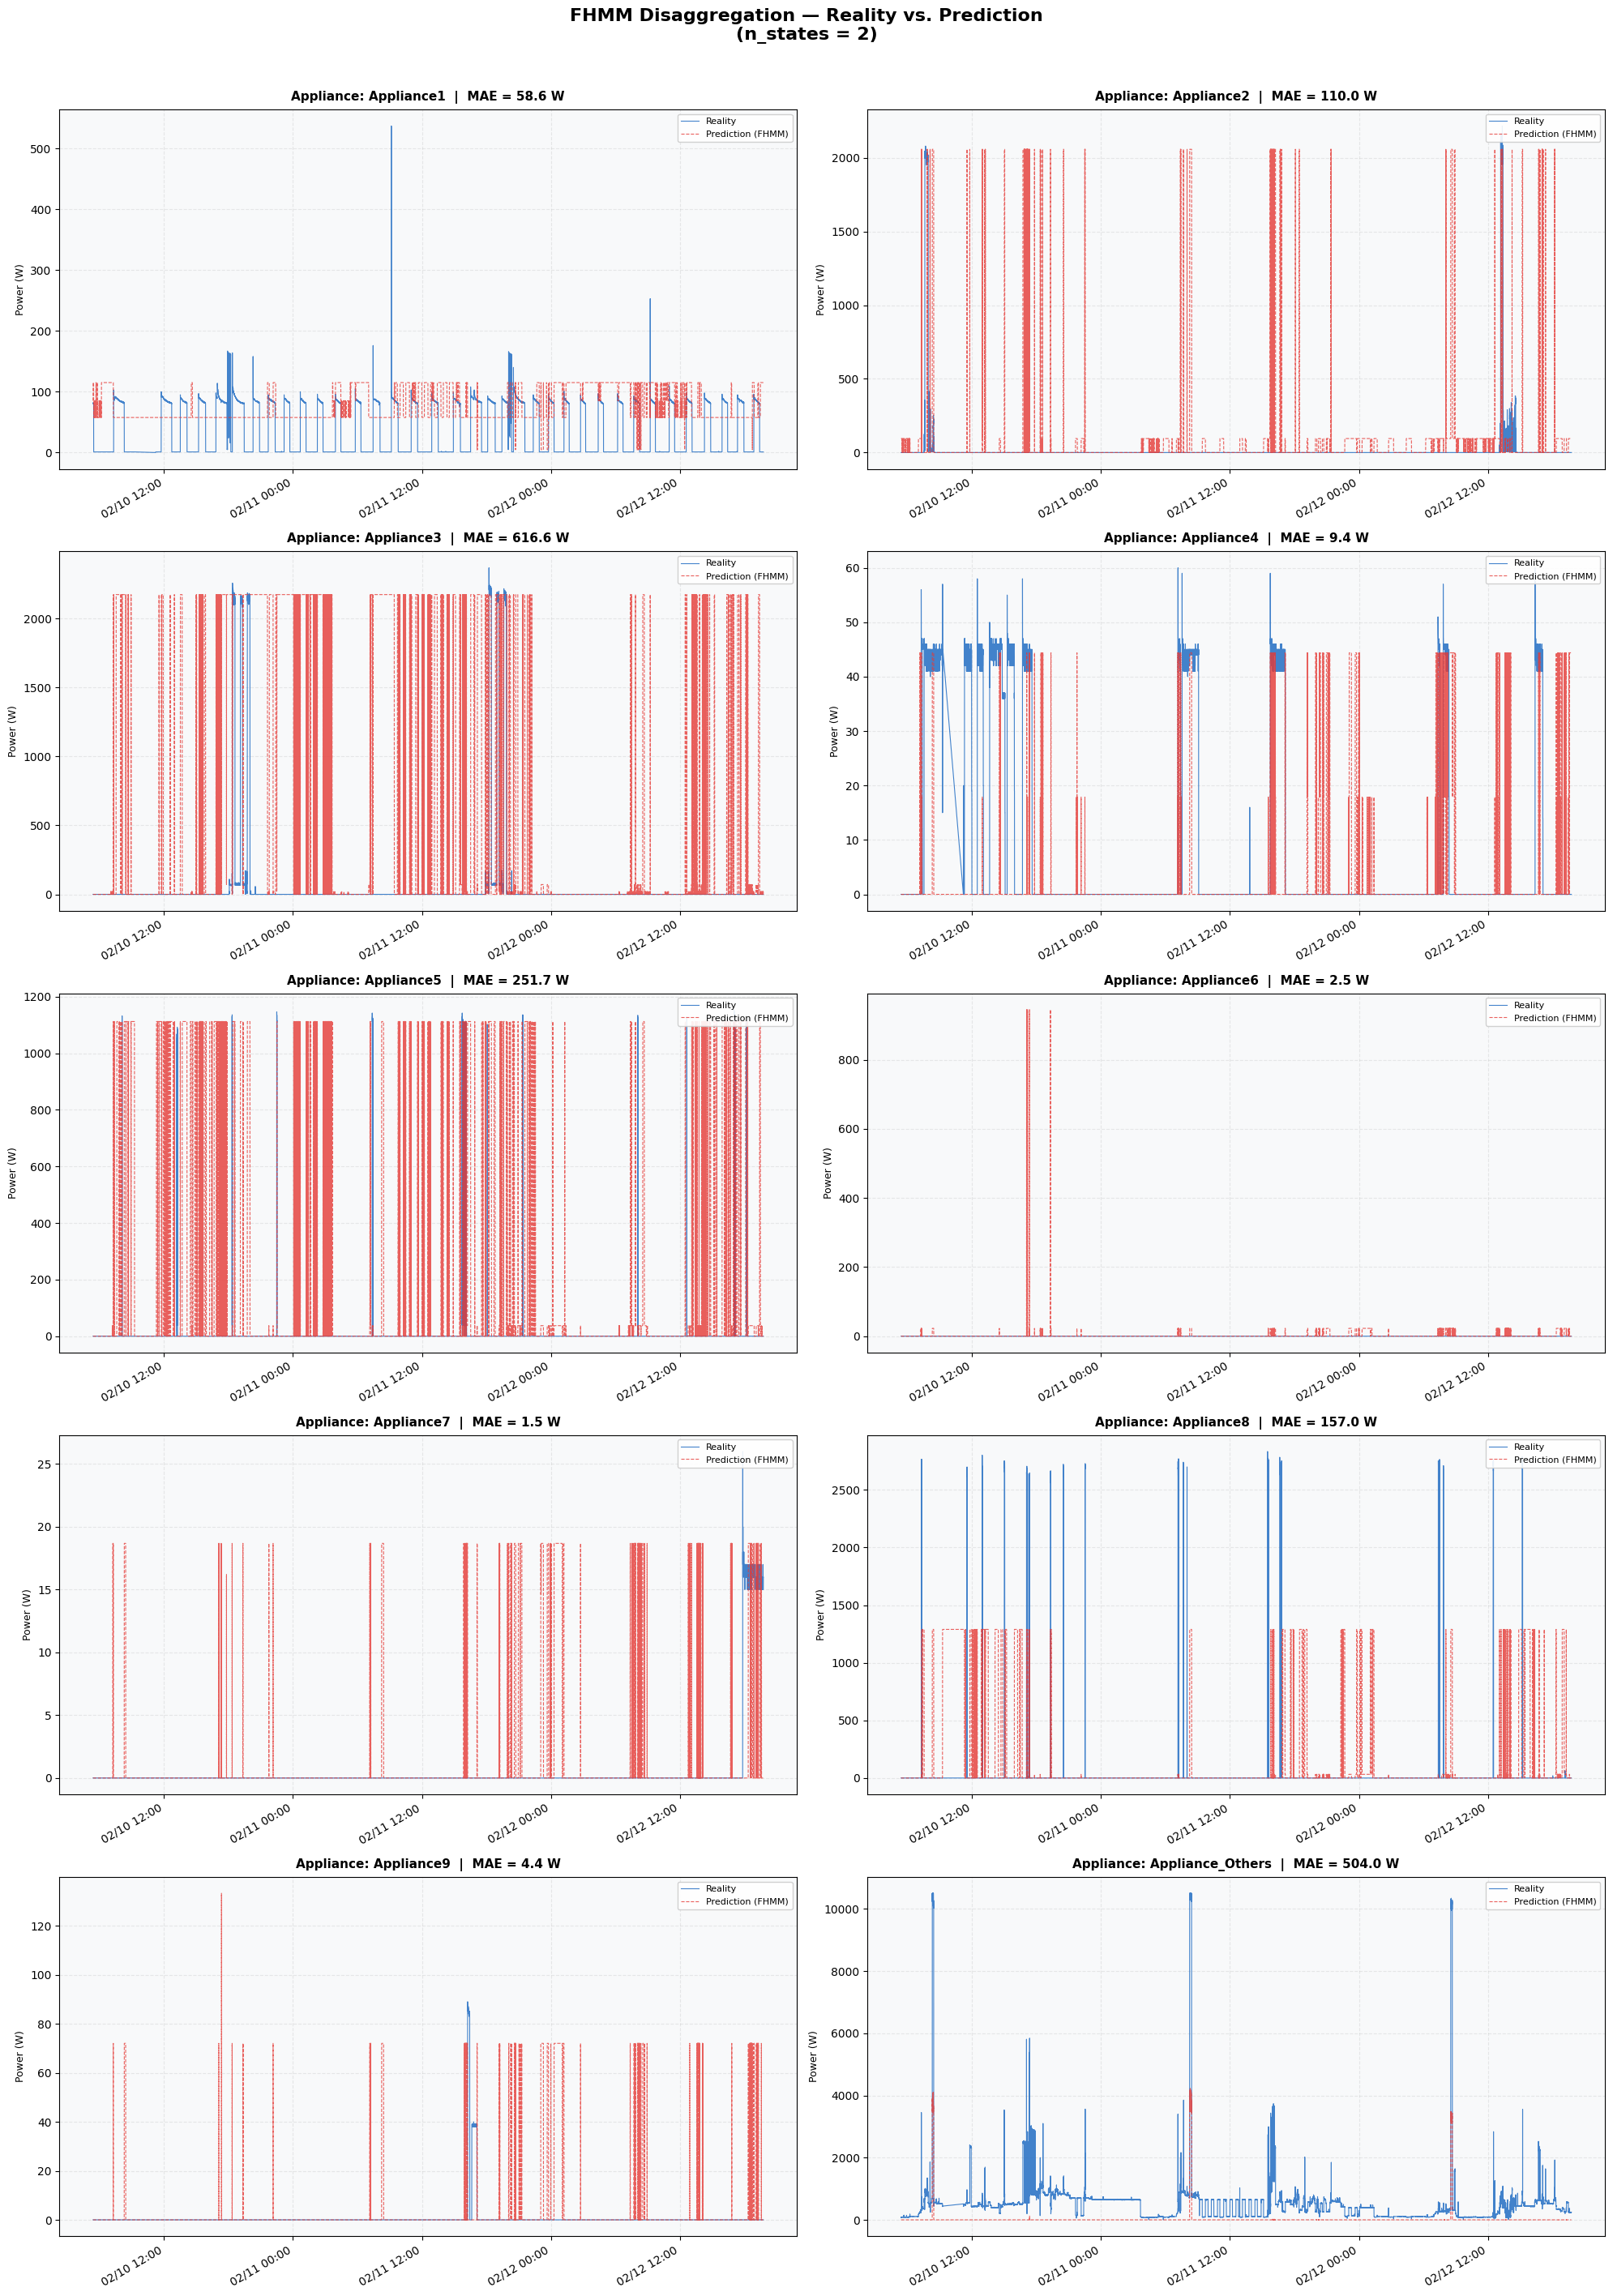

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# Đã bỏ .iloc[WINDOW_SIZE:] vì df_test giờ được lấy nguyên vẹn
time_test = df_test['Time'].reset_index(drop=True)

N_PLOT = min(32_400, len(time_test))

all_appliances = ['Appliance1', 'Appliance2', 'Appliance3',
                  'Appliance4', 'Appliance5', 'Appliance6',
                  'Appliance7', 'Appliance8', 'Appliance9',
                  'Appliance_Others']

colors_actual = '#1565C0'  
colors_pred   = '#E53935' 

fig, axes = plt.subplots(5, 2, figsize=(20, 28))
axes = axes.flatten()  # chuyển từ 2D array sang 1D

for i, col in enumerate(all_appliances):
    ax = axes[i]
    
    t = time_test[:N_PLOT]
    actual = y_test[col].values[:N_PLOT]
    predicted = y_pred_df[col].values[:N_PLOT]
    
    ax.plot(t, actual, 
            color=colors_actual, linewidth=0.8, alpha=0.8,
            label='Reality', zorder=2)
    
    ax.plot(t, predicted, 
            color=colors_pred, linewidth=0.8, alpha=0.8,
            label='Prediction (FHMM)', linestyle='--', zorder=3)

    mae_val = np.abs(actual - predicted).mean()
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    
    ax.set_title(f'Appliance: {col}  |  MAE = {mae_val:.1f} W', 
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel('Power (W)', fontsize=9)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.25, linestyle='--')
    
    ax.set_facecolor('#F8F9FA')

for j in range(len(all_appliances), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'FHMM Disaggregation — Reality vs. Prediction\n'
             f'(n_states = {best_model.n_states})',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()

output_path = 'fhmm_results.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')

plt.show()